In [23]:
# Import packages
import json
from huggingface_hub import login
from transformers import AutoModel, AutoModelForCausalLM, AutoTokenizer, pipeline
import transformers
import random
import torch
import time
import re
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold


# Set GPUs
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3,5"

print("Available GPUs:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

# Set seeds
random.seed(0)
torch.manual_seed(0)


Available GPUs: 2
GPU 0: NVIDIA A100-SXM4-40GB
GPU 1: NVIDIA A100-SXM4-40GB


In [9]:
# Generate simulated dataset
# Simulated dataset for binary classification
def generate_simulated_data(num_samples=100, embedding_size=768):
    # Random embeddings (simulating BioBERT output)
    X = np.random.rand(num_samples, embedding_size).astype(np.float32)
    
    # Simulating binary labels
    y = np.random.randint(0, 2, size=num_samples)
    
    # Converting to PyTorch tensors
    X_tensor = torch.tensor(X)
    y_tensor = torch.tensor(y)
    
    return X_tensor, y_tensor

X, y = generate_simulated_data(num_samples=100, embedding_size=768)
torch.save((X, y), 'simulated_data.pt')
print("Simulated dataset saved as 'simulated_data.pt'")

Simulated dataset saved as 'simulated_data.pt'


In [8]:
# Dataset preprocessing
# Load simulated data
def load_data(path='simulated_data.pt'):
    X, y = torch.load(path)
    return X, y

# Split dataset into training and testing sets
def train_test_split_data(X, y, test_size=0.2):
    return train_test_split(X, y, test_size=test_size, random_state=42)

X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split_data(X, y)
torch.save((X_train, X_test, y_train, y_test), 'train_test_split.pt')
print("Train-test split saved as 'train_test_split.pt'")

Train-test split saved as 'train_test_split.pt'


In [16]:
# Model setups
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

# Logistic Regression Model
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionModel, self).__init__()
        self.fc = nn.Linear(input_dim, 2)

    def forward(self, x):
        return self.fc(x)

# MLP Model
class MLPModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        _, h_n = self.gru(x)
        return self.fc(h_n[-1])

# Function to select model
def get_model(model_name, input_dim):
    if model_name == 'logistic_regression':
        return LogisticRegressionModel(input_dim)
    elif model_name == 'mlp':
        return MLPModel(input_dim)
    else:
        raise ValueError(f"Unknown model: {model_name}")

# Example usage
model = get_model('logistic_regression', 768)  # Input dim of BioBERT embeddings (768 for base model)
print(model)


LogisticRegressionModel(
  (fc): Linear(in_features=768, out_features=2, bias=True)
)


In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

LogisticRegressionModel(
  (fc): Linear(in_features=768, out_features=2, bias=True)
)

In [17]:
import torch
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Train the model using k-fold cross-validation
def train_model(X_train, y_train, model, epochs=10, batch_size=32, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    kfold = KFold(n_splits=5, shuffle=True)
    
    all_fpr_train = np.array([])  # To store false positive rates for training AUROC
    all_tpr_train = np.array([])  # To store true positive rates for training AUROC
    all_thresholds_train = np.array([])  # To store thresholds for training AUROC
    
    all_fpr_test = np.array([])  # To store false positive rates for test AUROC
    all_tpr_test = np.array([])  # To store true positive rates for test AUROC
    all_thresholds_test = np.array([])  # To store thresholds for test AUROC

    # K-Fold Cross-Validation Loop (only for training)
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
        X_train_fold, y_train_fold = X_train[train_idx], y_train[train_idx]
        X_val_fold, y_val_fold = X_train[val_idx], y_train[val_idx]
        
        # Training loop with tqdm
        for epoch in tqdm(range(epochs), desc=f"Fold {fold+1} Training", leave=False):
            model.train()
            optimizer.zero_grad()
            outputs = model(X_train_fold.to(device))
            loss = criterion(outputs, y_train_fold.to(device))
            loss.backward()
            optimizer.step()

    # Evaluation on the training and test set after training
    model.eval()
    metrics = {}
    with torch.no_grad():
        # Training set evaluation
        X_train_tensor = torch.tensor(X_train).to(device)
        y_train_tensor = torch.tensor(y_train).to(device)
        train_outputs = model(X_train_tensor)
        _, predicted_train = torch.max(train_outputs, 1)

        # Compute training metrics
        accuracy_train = accuracy_score(y_train, predicted_train.cpu())
        precision_train = precision_score(y_train, predicted_train.cpu(), average='binary')
        recall_train = recall_score(y_train, predicted_train.cpu(), average='binary')
        f1_train = f1_score(y_train, predicted_train.cpu(), average='binary')
        auc_train = roc_auc_score(y_train, train_outputs.cpu()[:, 1])

        # Store training metrics
        metrics['train'] = {
            'accuracy': accuracy_train,
            'precision': precision_train,
            'recall': recall_train,
            'f1': f1_train,
            'auc': auc_train
        }

        # AUROC curve data for training set
        fpr_train, tpr_train, thresholds_train = roc_curve(y_train, train_outputs.cpu()[:, 1])
        all_fpr_train = np.concatenate((all_fpr_train, fpr_train))
        all_tpr_train = np.concatenate((all_tpr_train, tpr_train))
        all_thresholds_train = np.concatenate((all_thresholds_train, thresholds_train))
        
        print(f"Training Set - Accuracy: {accuracy_train:.4f}, Precision: {precision_train:.4f}, Recall: {recall_train:.4f}, F1: {f1_train:.4f}, AUC: {auc_train:.4f}")
        
        # Test set evaluation
        X_test_tensor = torch.tensor(X_test).to(device)
        y_test_tensor = torch.tensor(y_test).to(device)
        test_outputs = model(X_test_tensor)
        _, predicted_test = torch.max(test_outputs, 1)

        # Compute test metrics
        accuracy_test = accuracy_score(y_test, predicted_test.cpu())
        precision_test = precision_score(y_test, predicted_test.cpu(), average='binary')
        recall_test = recall_score(y_test, predicted_test.cpu(), average='binary')
        f1_test = f1_score(y_test, predicted_test.cpu(), average='binary')
        auc_test = roc_auc_score(y_test, test_outputs.cpu()[:, 1])

        # Store test metrics
        metrics['test'] = {
            'accuracy': accuracy_test,
            'precision': precision_test,
            'recall': recall_test,
            'f1': f1_test,
            'auc': auc_test
        }

        print(f"Test Set - Accuracy: {accuracy_test:.4f}, Precision: {precision_test:.4f}, Recall: {recall_test:.4f}, F1: {f1_test:.4f}, AUC: {auc_test:.4f}")
        
        # AUROC curve data for test set
        fpr_test, tpr_test, thresholds_test = roc_curve(y_test, test_outputs.cpu()[:, 1])
        all_fpr_test = np.concatenate((all_fpr_test, fpr_test))
        all_tpr_test = np.concatenate((all_tpr_test, tpr_test))
        all_thresholds_test = np.concatenate((all_thresholds_test, thresholds_test))

    # Plot the AUROC curve for both training and test sets
    plt.figure()
    plt.plot(all_fpr_train, all_tpr_train, color='b', label=f'Training ROC curve (area = {metrics["train"]["auc"]:.2f})')
    plt.plot(all_fpr_test, all_tpr_test, color='r', label=f'Test ROC curve (area = {metrics["test"]["auc"]:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (Training and Test Sets)')
    plt.legend(loc='lower right')
    plt.show()

    return model, metrics

# Example usage
# if __name__ == "__main__":
#     from dataset_preprocessing import load_data, train_test_split_data
#     from model_setup import get_model

X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split_data(X, y)

model = get_model('logistic_regression', X_train.shape[1])
trained_model, metrics = train_model(X_train, y_train, model)

torch.save(trained_model.state_dict(), 'best_model.pt')


NameError: name 'KFold' is not defined

/tmp/ipykernel_3348729/314283663.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train).to(device)
/tmp/ipykernel_3348729/314283663.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train).to(device)
/tmp/ipykernel_3348729/314283663.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test).to(device)
/tmp/ipykernel_3348729/314283663.py:77: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach

Training Set - Accuracy: 1.0000, Precision: 1.0000, Recall: 1.0000, F1: 1.0000, AUC: 1.0000
Test Set - Accuracy: 0.6500, Precision: 0.6000, Recall: 0.6667, F1: 0.6316, AUC: 0.6869


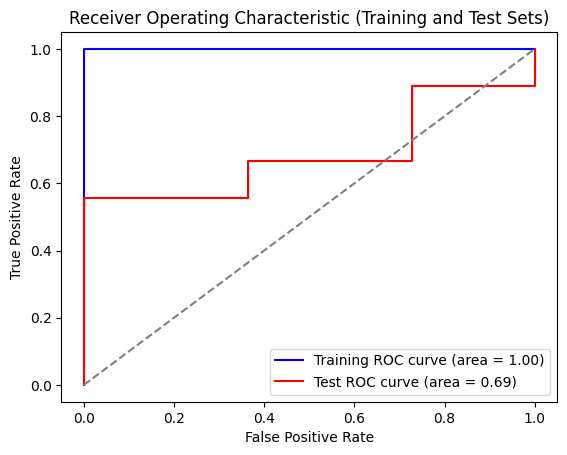

In [19]:
import torch
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

# Train the model using k-fold cross-validation
def train_model(X_train, y_train, model, epochs=10, batch_size=32, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    kfold = KFold(n_splits=5, shuffle=True)
    
    all_fpr_train = np.array([])  # To store false positive rates for training AUROC
    all_tpr_train = np.array([])  # To store true positive rates for training AUROC
    all_thresholds_train = np.array([])  # To store thresholds for training AUROC
    
    all_fpr_test = np.array([])  # To store false positive rates for test AUROC
    all_tpr_test = np.array([])  # To store true positive rates for test AUROC
    all_thresholds_test = np.array([])  # To store thresholds for test AUROC

    # K-Fold Cross-Validation Loop (only for training)
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
        X_train_fold, y_train_fold = X_train[train_idx], y_train[train_idx]
        X_val_fold, y_val_fold = X_train[val_idx], y_train[val_idx]
        
        # Training loop with tqdm
        for epoch in tqdm(range(epochs), desc=f"Fold {fold+1} Training", leave=False):
            model.train()
            optimizer.zero_grad()
            outputs = model(X_train_fold.to(device))
            loss = criterion(outputs, y_train_fold.to(device))
            loss.backward()
            optimizer.step()

    # Evaluation on the training and test set after training
    model.eval()
    metrics = {}
    with torch.no_grad():
        # Training set evaluation
        X_train_tensor = torch.tensor(X_train).to(device)
        y_train_tensor = torch.tensor(y_train).to(device)
        train_outputs = model(X_train_tensor)
        _, predicted_train = torch.max(train_outputs, 1)

        # Compute training metrics
        accuracy_train = accuracy_score(y_train, predicted_train.cpu())
        precision_train = precision_score(y_train, predicted_train.cpu(), average='binary')
        recall_train = recall_score(y_train, predicted_train.cpu(), average='binary')
        f1_train = f1_score(y_train, predicted_train.cpu(), average='binary')
        auc_train = roc_auc_score(y_train, train_outputs.cpu()[:, 1])

        # Store training metrics
        metrics['train'] = {
            'accuracy': accuracy_train,
            'precision': precision_train,
            'recall': recall_train,
            'f1': f1_train,
            'auc': auc_train
        }

        # AUROC curve data for training set
        fpr_train, tpr_train, thresholds_train = roc_curve(y_train, train_outputs.cpu()[:, 1])
        all_fpr_train = np.concatenate((all_fpr_train, fpr_train))
        all_tpr_train = np.concatenate((all_tpr_train, tpr_train))
        all_thresholds_train = np.concatenate((all_thresholds_train, thresholds_train))
        
        print(f"Training Set - Accuracy: {accuracy_train:.4f}, Precision: {precision_train:.4f}, Recall: {recall_train:.4f}, F1: {f1_train:.4f}, AUC: {auc_train:.4f}")
        
        # Test set evaluation
        X_test_tensor = torch.tensor(X_test).to(device)
        y_test_tensor = torch.tensor(y_test).to(device)
        test_outputs = model(X_test_tensor)
        _, predicted_test = torch.max(test_outputs, 1)

        # Compute test metrics
        accuracy_test = accuracy_score(y_test, predicted_test.cpu())
        precision_test = precision_score(y_test, predicted_test.cpu(), average='binary')
        recall_test = recall_score(y_test, predicted_test.cpu(), average='binary')
        f1_test = f1_score(y_test, predicted_test.cpu(), average='binary')
        auc_test = roc_auc_score(y_test, test_outputs.cpu()[:, 1])

        # Store test metrics
        metrics['test'] = {
            'accuracy': accuracy_test,
            'precision': precision_test,
            'recall': recall_test,
            'f1': f1_test,
            'auc': auc_test
        }

        print(f"Test Set - Accuracy: {accuracy_test:.4f}, Precision: {precision_test:.4f}, Recall: {recall_test:.4f}, F1: {f1_test:.4f}, AUC: {auc_test:.4f}")
        
        # AUROC curve data for test set
        fpr_test, tpr_test, thresholds_test = roc_curve(y_test, test_outputs.cpu()[:, 1])
        all_fpr_test = np.concatenate((all_fpr_test, fpr_test))
        all_tpr_test = np.concatenate((all_tpr_test, tpr_test))
        all_thresholds_test = np.concatenate((all_thresholds_test, thresholds_test))

    # Store AUROC curve data in the metrics dictionary
    metrics['train_roc'] = {'fpr': all_fpr_train, 'tpr': all_tpr_train}
    metrics['test_roc'] = {'fpr': all_fpr_test, 'tpr': all_tpr_test}

    # Plot the AUROC curve for both training and test sets
    plt.figure()
    plt.plot(all_fpr_train, all_tpr_train, color='b', label=f'Training ROC curve (area = {metrics["train"]["auc"]:.2f})')
    plt.plot(all_fpr_test, all_tpr_test, color='r', label=f'Test ROC curve (area = {metrics["test"]["auc"]:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (Training and Test Sets)')
    plt.legend(loc='lower right')
    plt.show()

    return model, metrics, all_fpr_train, all_tpr_train, all_fpr_test, all_tpr_test

# Example usage
# if __name__ == "__main__":
#     from dataset_preprocessing import load_data, train_test_split_data
#     from model_setup import get_model

X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split_data(X, y)

model = get_model('logistic_regression', X_train.shape[1])
trained_model, metrics, fpr_train, tpr_train, fpr_test, tpr_test = train_model(X_train, y_train, model)
torch.save(trained_model.state_dict(), 'best_model.pt')


In [45]:
# Store results in pickle file
import pickle

with open("metrics.pkl", "wb") as f:
    pickle.dump(metrics, f)

with open("metrics.pkl", "rb") as f:
    loaded_dict = pickle.load(f)

loaded_dict

{'train': {'accuracy': 1.0,
  'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'auc': 1.0},
 'test': {'accuracy': 0.5,
  'precision': 0.42857142857142855,
  'recall': 0.3333333333333333,
  'f1': 0.375,
  'auc': 0.5454545454545455},
 'train_roc': {'fpr': array([0., 0., 0., 1.]),
  'tpr': array([0.        , 0.02222222, 1.        , 1.        ])},
 'test_roc': {'fpr': array([0.        , 0.09090909, 0.18181818, 0.18181818, 0.45454545,
         0.45454545, 0.63636364, 0.63636364, 0.72727273, 0.72727273,
         0.90909091, 0.90909091, 1.        ]),
  'tpr': array([0.        , 0.        , 0.        , 0.44444444, 0.44444444,
         0.55555556, 0.55555556, 0.77777778, 0.77777778, 0.88888889,
         0.88888889, 1.        , 1.        ])}}